# Mini-Projekt 1: Regression von Hand — Lösung

Aufgabenbeschreibung und Erfolgskriterien findest du auf der Projektseite der Kurs-Website.
Ziel: eine lineare Regression mit Gradientenabstieg **nur mit NumPy** – und am Ende derselbe Test-Fehler wie scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)
rng = np.random.default_rng(42)

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes(scaled=False)
X, y = data.data, data.target
namen = data.feature_names
print(X.shape, y.shape)
print(namen)

(442, 10) (442,)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Schritt 1: Erkunden

age   Mittelwert    48.52   Std   13.09
sex   Mittelwert     1.47   Std    0.50
bmi   Mittelwert    26.38   Std    4.41
bp    Mittelwert    94.65   Std   13.82
s1    Mittelwert   189.14   Std   34.57
s2    Mittelwert   115.44   Std   30.38
s3    Mittelwert    49.79   Std   12.92
s4    Mittelwert     4.07   Std    1.29
s5    Mittelwert     4.64   Std    0.52
s6    Mittelwert    91.26   Std   11.48
stärkste Korrelation: bmi 0.586


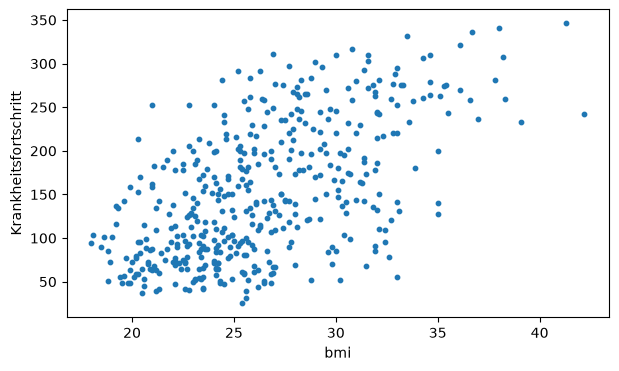

In [3]:
# Mittelwert und Standardabweichung jedes Features ausgeben
for name, m, s in zip(namen, X.mean(axis=0), X.std(axis=0)):
    print(f"{name:4s}  Mittelwert {m:8.2f}   Std {s:7.2f}")
# Korrelation jedes Features mit y; das stärkste Feature bestimmen
korrelationen = np.array([np.corrcoef(X[:, j], y)[0, 1] for j in range(X.shape[1])])
j_best = np.argmax(np.abs(korrelationen))
print("stärkste Korrelation:", namen[j_best], round(korrelationen[j_best], 3))
plt.scatter(X[:, j_best], y, s=10); plt.xlabel(namen[j_best]); plt.ylabel("Krankheitsfortschritt"); plt.show()

## Schritt 2: Aufteilen in Training und Test (80/20)

In [4]:
# zufällige Permutation mit Seed 42, die ersten 80 % sind Training
idx = np.random.default_rng(42).permutation(len(y))
n_train = int(0.8 * len(y))
train_idx, test_idx = idx[:n_train], idx[n_train:]
X_train, X_test, y_train, y_test = X[train_idx], X[test_idx], y[train_idx], y[test_idx]
print(X_train.shape, X_test.shape)

(353, 10) (89, 10)


## Schritt 3: Standardisieren

Mittelwert und Standardabweichung **nur aus den Trainingsdaten** – sonst fließt Information aus dem Test-Satz ins Training (*Data Leakage*).

In [5]:
def standardisierer(X_train):
    # Mittelwert und Std der Trainingsdaten berechnen und eine Transformationsfunktion zurückgeben
    mu, sd = X_train.mean(axis=0), X_train.std(axis=0)
    return lambda X: (X - mu) / sd

transform = standardisierer(X_train)
Z_train, Z_test = transform(X_train), transform(X_test)
print(np.round(Z_train.mean(axis=0), 6))
print(np.round(Z_train.std(axis=0), 6))

[ 0. -0. -0. -0.  0. -0.  0. -0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Schritt 4 und 5: Gradient implementieren und prüfen

In [6]:
def vorhersage(X, w, b):
    return X @ w + b

def mse(X, y, w, b):
    return np.mean((vorhersage(X, w, b) - y) ** 2)

def mse_gradient(X, y, w, b):
    # Gradienten nach w (Vektor) und b (Zahl)
    r = vorhersage(X, w, b) - y
    return 2 / len(y) * X.T @ r, 2 / len(y) * r.sum()

def num_gradient(X, y, w, b, h=1e-5):
    gw = np.zeros_like(w)
    for i in range(len(w)):
        e = np.zeros_like(w); e[i] = h
        gw[i] = (mse(X, y, w + e, b) - mse(X, y, w - e, b)) / (2 * h)
    gb = (mse(X, y, w, b + h) - mse(X, y, w, b - h)) / (2 * h)
    return gw, gb

w_test, b_test = rng.normal(size=X.shape[1]), 10.0
gw, gb = mse_gradient(Z_train, y_train, w_test, b_test)
gw_n, gb_n = num_gradient(Z_train, y_train, w_test, b_test)
print("relative Abweichung:", np.max(np.abs(gw - gw_n)) / np.max(np.abs(gw)), abs(gb - gb_n) / abs(gb))

relative Abweichung: 2.9582222854726203e-09 3.084994858959628e-10


## Schritt 4 (Fortsetzung): Modell nur mit BMI

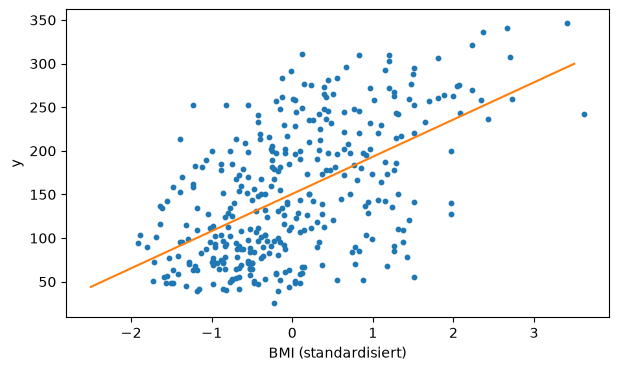

Test-MSE nur mit BMI: 3529.0657835896563


In [7]:
def train(X, y, lr, epochen):
    w, b = np.zeros(X.shape[1]), 0.0
    verlauf = []
    for _ in range(epochen):
        # ein Gradientenschritt, dann Verlust protokollieren
        gw, gb = mse_gradient(X, y, w, b)
        w, b = w - lr * gw, b - lr * gb
        verlauf.append(mse(X, y, w, b))
    return w, b, verlauf

j_bmi = namen.index("bmi")
w1, b1, _ = train(Z_train[:, [j_bmi]], y_train, lr=0.1, epochen=500)
plt.scatter(Z_train[:, j_bmi], y_train, s=10)
t = np.linspace(-2.5, 3.5, 2); plt.plot(t, w1[0] * t + b1, color="tab:orange")
plt.xlabel("BMI (standardisiert)"); plt.ylabel("y"); plt.show()
print("Test-MSE nur mit BMI:", mse(Z_test[:, [j_bmi]], y_test, w1, b1))

## Schritt 6: Alle Features, verschiedene Lernraten

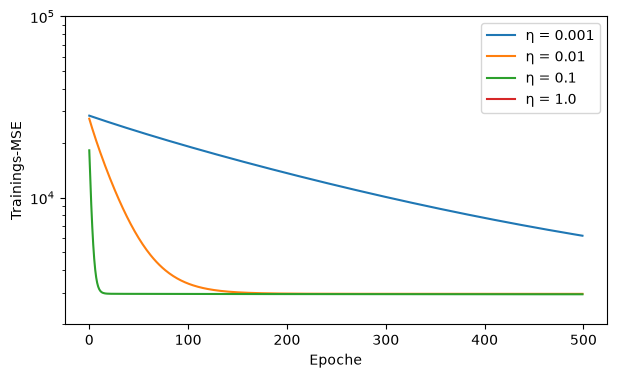

In [8]:
with np.errstate(over="ignore", invalid="ignore"):   # η = 1.0 divergiert absichtlich
    for lr in [0.001, 0.01, 0.1, 1.0]:
        w, b, verlauf = train(Z_train, y_train, lr, epochen=500)
        verlauf = np.nan_to_num(verlauf, nan=1e9, posinf=1e9)   # divergierte Werte für den Plot kappen
        plt.plot(np.minimum(verlauf, 1e9), label=f"η = {lr}")
plt.yscale("log"); plt.ylim(2e3, 1e5); plt.xlabel("Epoche"); plt.ylabel("Trainings-MSE"); plt.legend(); plt.show()

$\eta = 1{,}0$ divergiert, obwohl bei einem einzelnen standardisierten Feature sogar Lernraten bis 1 funktionieren würden.
Die maximale stabile Lernrate hängt von der stärksten Krümmung der Verlustlandschaft ab: Einige Blutwerte (`s1`, `s2`) sind stark
miteinander korreliert, was die Landschaft in eine Richtung sehr steil macht. Hier liegt die Grenze bei etwa $\eta \approx 0{,}26$.

Wir trainieren das finale Modell mit $\eta = 0{,}1$ und genügend Epochen.

In [9]:
w_gd, b_gd, verlauf = train(Z_train, y_train, lr=0.1, epochen=20_000)
mse_test_gd = mse(Z_test, y_test, w_gd, b_gd)
baseline = np.mean((y_test - y_train.mean()) ** 2)
print(f"Test-MSE: {mse_test_gd:.1f}   Baseline (immer Mittelwert): {baseline:.1f}   R² = {1 - mse_test_gd / np.var(y_test):.3f}")

Test-MSE: 2594.6   Baseline (immer Mittelwert): 6425.4   R² = 0.593


## Schritt 7: Mini-Batch-Gradientenabstieg

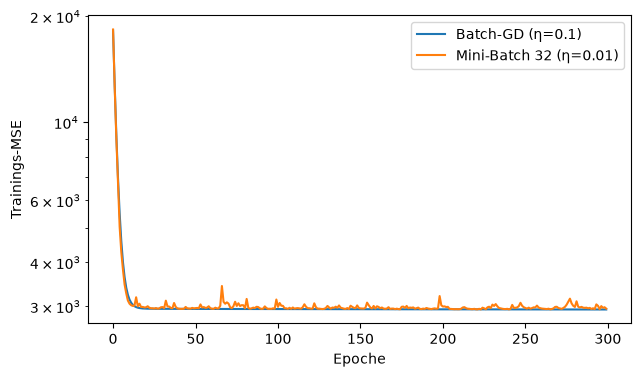

In [10]:
def train_minibatch(X, y, lr, epochen, batch=32, seed=0):
    r_gen = np.random.default_rng(seed)
    w, b = np.zeros(X.shape[1]), 0.0
    verlauf = []
    for _ in range(epochen):
        # Daten mischen, in Batches durchgehen, auf jedem Batch einen Schritt machen
        idx = r_gen.permutation(len(y))
        for s in range(0, len(y), batch):
            sel = idx[s:s + batch]
            gw, gb = mse_gradient(X[sel], y[sel], w, b)
            w, b = w - lr * gw, b - lr * gb
        verlauf.append(mse(X, y, w, b))
    return w, b, verlauf

_, _, v_batch = train(Z_train, y_train, 0.1, 300)
w_mb, b_mb, v_mb = train_minibatch(Z_train, y_train, 0.01, 300)
plt.plot(v_batch, label="Batch-GD (η=0.1)"); plt.plot(v_mb, label="Mini-Batch 32 (η=0.01)")
plt.yscale("log"); plt.xlabel("Epoche"); plt.ylabel("Trainings-MSE"); plt.legend(); plt.show()

## Schritt 8: Vergleich mit scikit-learn

In [11]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(Z_train, y_train)
mse_test_sk = np.mean((sk.predict(Z_test) - y_test) ** 2)
print(f"{'Feature':6s} {'unser GD':>10s} {'sklearn':>10s}")
for name, a, c in zip(namen, w_gd, sk.coef_):
    print(f"{name:6s} {a:10.3f} {c:10.3f}")
print(f"Bias   {b_gd:10.3f} {sk.intercept_:10.3f}")
print(f"Test-MSE: unser {mse_test_gd:.2f}  sklearn {mse_test_sk:.2f}")
print("max. relative Abweichung der Gewichte:", np.max(np.abs(w_gd - sk.coef_) / np.abs(sk.coef_)))

Feature   unser GD    sklearn
age        -0.365     -0.365
sex        -9.733     -9.733
bmi        23.653     23.653
bp         14.694     14.694
s1        -37.212    -37.212
s2         21.809     21.809
s3          4.923      4.923
s4          8.677      8.677
s5         36.447     36.447
s6          2.226      2.226
Bias      150.637    150.637
Test-MSE: unser 2594.63  sklearn 2594.63
max. relative Abweichung der Gewichte: 1.596563139189929e-13


## Schritt 9: Ohne Standardisierung

In [12]:
# Trainiere auf den unskalierten X_train mit verschiedenen Lernraten (200 Epochen) und gib den letzten Verlust aus
with np.errstate(over="ignore", invalid="ignore"):
    for lr in [1e-1, 1e-3, 1e-5, 1e-6]:
        _, _, v = train(X_train, y_train, lr, 200)
        print(f"η = {lr:g}: letzter Trainings-MSE = {v[-1]:.4g}")

η = 0.1: letzter Trainings-MSE = nan
η = 0.001: letzter Trainings-MSE = nan
η = 1e-05: letzter Trainings-MSE = 4110
η = 1e-06: letzter Trainings-MSE = 5168


Ohne Skalierung reichen die Features von ca. 1 (Geschlecht) bis über 200 (Cholesterin). Die Verlustlandschaft ist extrem langgezogen:
Für die großen Features ist sie so steil, dass nur winzige Lernraten stabil sind – und mit denen kommt man in den flachen Richtungen kaum voran.

## Schritt 10: Deuten

In [13]:
# Die drei Features mit den betragsmäßig größten Gewichten (standardisiert) ausgeben
for j in np.argsort(-np.abs(w_gd))[:3]:
    print(f"{namen[j]:4s} {w_gd[j]:8.2f}")

s1     -37.21
s5      36.45
bmi     23.65


Bei standardisierten Features bedeutet ein Gewicht: "Wie stark ändert sich die Vorhersage, wenn dieses Feature um eine Standardabweichung steigt?"
Damit sind Gewichte vergleichbar. Bei unskalierten Features hängt das Gewicht von der Einheit ab (mg/dl oder g/l?) und ist nicht vergleichbar.

**Vorsicht:** Bei stark korrelierten Features (hier `s1` und `s2`) können sich große Gewichte mit entgegengesetztem Vorzeichen gegenseitig aufheben.
Dieses Problem heißt **Multikollinearität** – Regularisierung (Ridge, Modul 3) hilft dagegen.